In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/cleaned_crime_nbh_2024.csv")

In [38]:
df.shape

(14494, 124)

In [39]:
df.columns

Index(['gwb_code_10', 'regio', 'gm_naam', 'ind_wbi', 'a_inw', 'a_man',
       'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44',
       ...
       'g_afs_sc', 'g_3km_sc', 'a_opp_ha', 'a_lan_ha', 'a_wat_ha', 'pst_mvp',
       'pst_dekp', 'ste_mvs', 'ste_oad', 'GeregistreerdeMisdrijven_1'],
      dtype='object', length=124)

### Removing columns with > 20% missing values

In [40]:
missing_20 = df.loc[:, df.isna().mean() >= 0.2]
missing_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14494 entries, 0 to 14493
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   p_stadsv     1087 non-null   float64
 1   p_won_z_ag   10140 non-null  float64
 2   p_won_m_ag   10140 non-null  float64
 3   p_won_zs     10140 non-null  float64
 4   p_won_ev     10140 non-null  float64
 5   a_lp_pub     0 non-null      float64
 6   a_opl_bvm    0 non-null      float64
 7   a_opl_hvm    0 non-null      float64
 8   a_opl_hw     0 non-null      float64
 9   a_arb_wz     0 non-null      float64
 10  p_arb_pp     0 non-null      float64
 11  p_arb_wn     0 non-null      float64
 12  p_arb_wnv    0 non-null      float64
 13  p_arb_wnf    0 non-null      float64
 14  p_arb_zs     0 non-null      float64
 15  a_inkont     0 non-null      float64
 16  g_ink_po     0 non-null      float64
 17  g_ink_pi     0 non-null      float64
 18  p_ink_li     0 non-null      float64
 19  p_in

In [41]:
# Save all columns with > 20% missing values as a variable
missing_20 = df.columns[df.isna().mean() >= 0.2].tolist()
for col in missing_20:
    print(col)

p_stadsv
p_won_z_ag
p_won_m_ag 
p_won_zs
p_won_ev 
a_lp_pub
a_opl_bvm
a_opl_hvm
a_opl_hw
a_arb_wz
p_arb_pp
p_arb_wn
p_arb_wnv
p_arb_wnf
p_arb_zs
a_inkont
g_ink_po
g_ink_pi
p_ink_li
p_ink_hi
g_hh_sti
p_hh_li
p_hh_hi
p_hh_lkk
p_hh_osm
p_hh_110
p_hh_120
m_hh_ver
a_jz_tn
p_jz_tn
a_wmo_t
p_wmo_t
g_pau_hh
g_pau_km


In [42]:
df = df.drop(columns=missing_20)

In [43]:
df.shape

(14494, 90)

In [44]:
missing = df.isna().mean().sort_values(ascending=False)

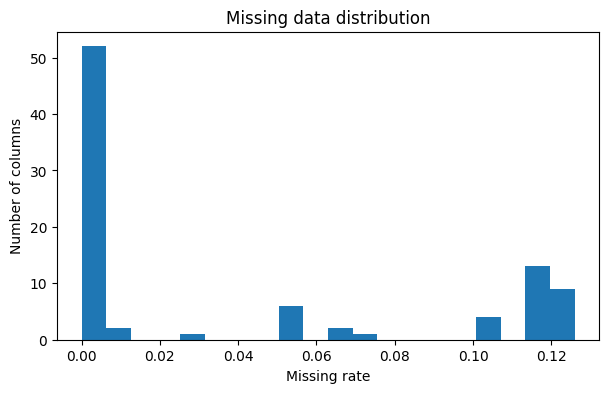

In [45]:
plt.figure(figsize=(7,4))
plt.hist(missing, bins=20)
plt.title("Missing data distribution")
plt.xlabel("Missing rate")
plt.ylabel("Number of columns")
plt.show()

### Removing neighborhoods with 0 population (a_inw)

In [46]:
# Remove rows where the total population ('a_inw') is 0 or missing
df = df[df['a_inw'].fillna(0) > 0]

### Imputing columns with < 20% missing values (median)

In [47]:
df = df.fillna(df.median(numeric_only=True))

### Alternative target variables (crime count & population)

Candidate outcomes for neighborhood crime models, built only from **`crime_count`** and **`population`**. Uses the **cleaned CSV** so rows with **zero population** can be flagged (those rows are removed later in the notebook). Does **not** duplicate `y_log_crime_rate_per_1k` / spillover columns from the pipeline below.


=== Population = 0 (or missing treated as 0) ===
Rows flagged: 475 / 14,494  (3.28%)
(These rows should not be used for rate-based targets; crime_count / log_crime_count may still be defined.)

=== Descriptive statistics (all rows where defined) ===

--- crime_rate_per_1000 (n=14,019) ---
count     14019.000000
mean        190.967322
std        3375.246549
min           0.000000
5%            6.250000
25%          16.706900
50%          29.333333
75%          59.468292
95%         410.079137
max      376400.000000

--- log_crime_count (n=14,494) ---
count    14494.000000
mean         3.093573
std          1.397204
min          0.000000
5%           0.693147
25%          2.197225
50%          3.135494
75%          4.060443
95%          5.314926
max          8.220134

--- log_crime_rate (n=14,019) ---
count    14019.000000
mean         3.576630
std          1.327538
min          0.000000
5%           1.981001
25%          2.873954
50%          3.412247
75%          4.102119
95%          

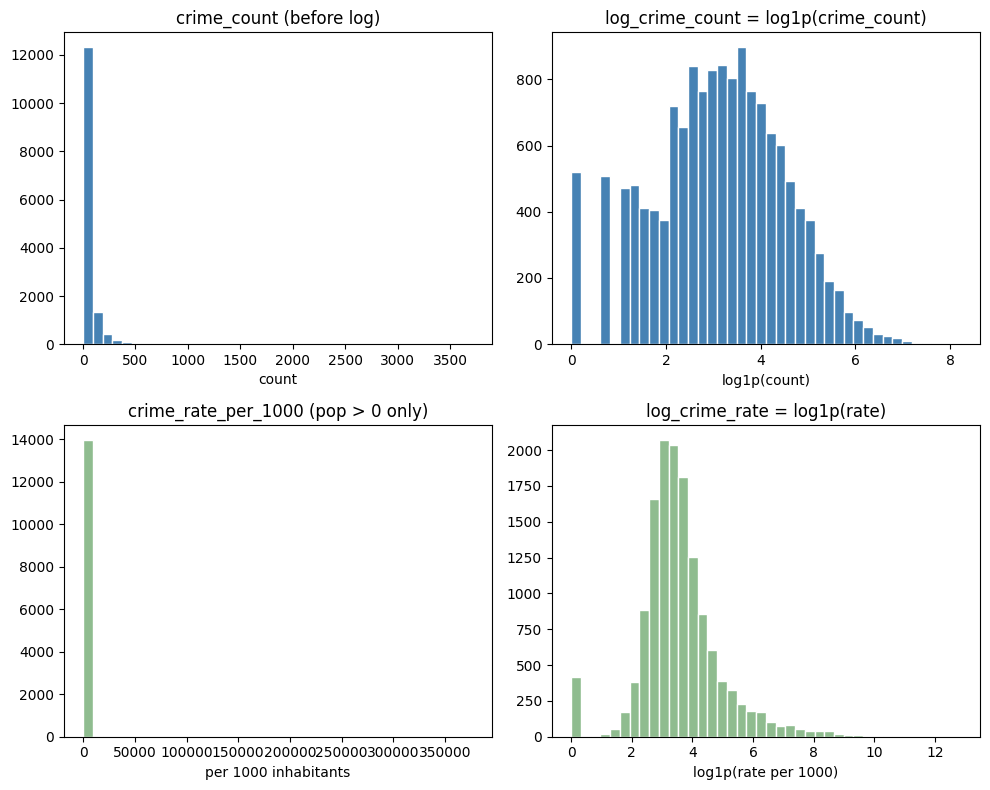


=== alternative_targets_summary (recommendation-ready) ===
             target     n     mean       std  min     p50         max    skew                                                     notes
crime_rate_per_1000 14019 190.9673 3375.2465  0.0 29.3333 376400.0000 99.7837      Level scale; sensitive to outliers; use pop > 0 only
    log_crime_count 14494   3.0936    1.3972  0.0  3.1355      8.2201 -0.0867   Stabilizes skewed counts; population not in denominator
     log_crime_rate 14019   3.5766    1.3275  0.0  3.4122     12.8384  0.7073 Stabilizes skewed rates; same scale as log1p(rate) models

Note: log_crime_rate is algebraically the same construction as log1p(1000*crimes/pop) and matches the pipeline's `y_log_crime_rate_per_1k` where both are defined.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Column mapping (edit if your file uses different names) ---
CRIME_COUNT_COL = "GeregistreerdeMisdrijven_1"
POPULATION_COL = "a_inw"
DATA_PATH = "datasets/cleaned_crime_nbh_2024.csv"

_raw = pd.read_csv(DATA_PATH)
crime_count = pd.to_numeric(_raw[CRIME_COUNT_COL], errors="coerce").astype(float)
population = pd.to_numeric(_raw[POPULATION_COL], errors="coerce").astype(float)

n_total = len(_raw)
pop_zero = population.fillna(0) <= 0
n_zero = int(pop_zero.sum())
pct_zero = 100.0 * n_zero / n_total if n_total else 0.0

print("=== Population = 0 (or missing treated as 0) ===")
print(f"Rows flagged: {n_zero:,} / {n_total:,}  ({pct_zero:.2f}%)")
print("(These rows should not be used for rate-based targets; crime_count / log_crime_count may still be defined.)")

valid_rate = population.fillna(0) > 0
crime_rate_per_1000 = np.where(valid_rate, 1000.0 * crime_count / population, np.nan)
log_crime_count = np.log1p(np.clip(crime_count, 0, None))
log_crime_rate = np.log1p(np.where(valid_rate, 1000.0 * crime_count / population, np.nan))

alt = pd.DataFrame(
    {
        "crime_count": crime_count,
        "population": population,
        "pop_zero_flag": pop_zero.astype(int),
        "crime_rate_per_1000": crime_rate_per_1000,
        "log_crime_count": log_crime_count,
        "log_crime_rate": log_crime_rate,
    },
    index=_raw.index,
)

print("\n=== Descriptive statistics (all rows where defined) ===")
for col in ["crime_rate_per_1000", "log_crime_count", "log_crime_rate"]:
    s = alt[col].dropna()
    print(f"\n--- {col} (n={len(s):,}) ---")
    print(s.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

# Histograms: before vs after log (count and rate)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(crime_count.clip(lower=0), bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("crime_count (before log)")
axes[0, 0].set_xlabel("count")

axes[0, 1].hist(log_crime_count, bins=40, color="steelblue", edgecolor="white")
axes[0, 1].set_title("log_crime_count = log1p(crime_count)")
axes[0, 1].set_xlabel("log1p(count)")

rate_valid = alt["crime_rate_per_1000"].dropna()
axes[1, 0].hist(rate_valid, bins=40, color="darkseagreen", edgecolor="white")
axes[1, 0].set_title("crime_rate_per_1000 (pop > 0 only)")
axes[1, 0].set_xlabel("per 1000 inhabitants")

lr_valid = alt["log_crime_rate"].dropna()
axes[1, 1].hist(lr_valid, bins=40, color="darkseagreen", edgecolor="white")
axes[1, 1].set_title("log_crime_rate = log1p(rate)")
axes[1, 1].set_xlabel("log1p(rate per 1000)")

plt.tight_layout()
plt.show()

# Recommendation-ready summary table
rows = []
for col in ["crime_rate_per_1000", "log_crime_count", "log_crime_rate"]:
    s = alt[col].dropna()
    rows.append(
        {
            "target": col,
            "n": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p50": s.median(),
            "max": s.max(),
            "skew": s.skew(),
        }
    )

alternative_targets_summary = pd.DataFrame(rows).round(
    {"mean": 4, "std": 4, "min": 4, "p50": 4, "max": 4, "skew": 4}
)
alternative_targets_summary["notes"] = [
    "Level scale; sensitive to outliers; use pop > 0 only",
    "Stabilizes skewed counts; population not in denominator",
    "Stabilizes skewed rates; same scale as log1p(rate) models",
]

print("\n=== alternative_targets_summary (recommendation-ready) ===")
print(alternative_targets_summary.to_string(index=False))

print(
    "\nNote: log_crime_rate is algebraically the same construction as log1p(1000*crimes/pop)"
    " and matches the pipeline's `y_log_crime_rate_per_1k` where both are defined."
)



## Reproducible preprocessing pipeline (tabular → target → geometry → spillover)

Run the cells **in order** after the steps above (or set `START_FROM_CSV = True` in block 1 to load `cleaned_crime_nbh_2024.csv` and repeat the tabular filters).

**Logic**

1. **Tabular only** — missing-data handling on the **non-geometric** dataset (same idea as the cells above: drop high-missing columns, population filter, median impute).
2. **Main target** — log crime rate per 1,000 inhabitants, **before** any geometry is attached.
3. **Geometric features** — attach polygons from notebook 1's GPKG, then build **spillover** variables (neighbor count + spatial lag of the main target).
4. **Missing data on geo-augmented data** — inspect and impute where needed (e.g. spillover lag for areas without neighbors).
5. **Spillover-model outcome** — explicit outcome column for models that include spillover regressors (same scale as the main target; documented for your write-up).


In [49]:
import geopandas as gpd
import numpy as np
import pandas as pd


### Block 1 — Tabular data only (no geometry)

Uses the imputed dataframe from the cells above (`df`). If you need a standalone run, set `START_FROM_CSV = True` to reload the cleaned CSV and re-apply the same rules: drop columns with ≥ 20% missing, drop rows with `a_inw` ≤ 0, median impute remaining numeric columns.


In [50]:
START_FROM_CSV = False

MISSING_COL_THRESHOLD = 0.2
POPULATION_COL = "a_inw"
TABULAR_PATH = "datasets/cleaned_crime_nbh_2024.csv"

if START_FROM_CSV:
    df_raw = pd.read_csv(TABULAR_PATH)
    missing_20 = df_raw.columns[df_raw.isna().mean() >= MISSING_COL_THRESHOLD].tolist()
    print(f"Dropping {len(missing_20)} columns with >= {MISSING_COL_THRESHOLD:.0%} missing")
    df_tab = df_raw.drop(columns=missing_20)
    before = len(df_tab)
    df_tab = df_tab[df_tab[POPULATION_COL].fillna(0) > 0]
    print(f"Population filter: {before} -> {len(df_tab)} rows ({POPULATION_COL} > 0)")
    df_tab = df_tab.fillna(df_tab.median(numeric_only=True))
else:
    df_tab = df.copy()

print("df_tab shape:", df_tab.shape)
miss = df_tab.isna().mean().sort_values(ascending=False)
print("Columns with any missing:", int((miss > 0).sum()), "/", len(miss))


df_tab shape: (14019, 90)
Columns with any missing: 0 / 90


### Block 2 — Main target (tabular only; no geographic variables)

`y_log_crime_rate_per_1k` = **log1p**( registered crimes per **1,000** inhabitants ). Built only from columns in `df_tab` (crime count + population).


In [51]:
CRIME_COL = "GeregistreerdeMisdrijven_1"

pop = df_tab[POPULATION_COL].astype(float)
crimes = df_tab[CRIME_COL].astype(float)
rate_per_1k = np.where(pop > 0, 1000.0 * crimes / pop, np.nan)
df_tab["y_log_crime_rate_per_1k"] = np.log1p(np.clip(rate_per_1k, 0, None))

y = df_tab["y_log_crime_rate_per_1k"]
print("y_log_crime_rate_per_1k — min:", round(y.min(), 4), "max:", round(y.max(), 4), "mean:", round(y.mean(), 4))


y_log_crime_rate_per_1k — min: 0.0 max: 12.8384 mean: 3.5766


### Block 3 — Geographic layer + spillover features

Attach **`geometry`** from `merged_crime_nbh_2024.gpkg` (notebook 1). Then compute **touching** neighbors and the **mean** of the main target on neighbors (`spillover_lag_...`) and **`spillover_neighbor_count`**. Missing lag values are left for the next block.


In [52]:
PROJECT_GEOM_GPKG_PATH = "datasets/merged_crime_nbh_2024.gpkg"
TABULAR_KEY_COL = "gwb_code_10"

def standardize_merge_key(s: pd.Series) -> pd.Series:
    return (
        s.astype(str).str.strip().str.replace(r"\s+", "", regex=True).str.upper().replace({"NAN": np.nan, "NONE": np.nan})
    )

geo = gpd.read_file(PROJECT_GEOM_GPKG_PATH)
geom_only = geo[[TABULAR_KEY_COL, "geometry"]].drop_duplicates(subset=[TABULAR_KEY_COL])
geom_only["merge_key"] = standardize_merge_key(geom_only[TABULAR_KEY_COL])
tab = df_tab.copy()
tab["merge_key"] = standardize_merge_key(tab[TABULAR_KEY_COL])
merged = tab.merge(geom_only[["merge_key", "geometry"]], on="merge_key", how="left")
gdf = gpd.GeoDataFrame(merged, geometry="geometry", crs=geo.crs)
matched = gdf.geometry.notna().sum()
print(f"Geometry attached: {matched} / {len(gdf)} rows ({100*matched/len(gdf):.2f}%)")

value_col = "y_log_crime_rate_per_1k"
out = gdf.reset_index(drop=True).copy()
out["_row_id"] = np.arange(len(out))
sub = out.dropna(subset=["geometry"]).copy()
left = sub[["_row_id", "geometry"]]
right = sub[["_row_id", value_col, "geometry"]].rename(columns={"_row_id": "_nbr_id"})
joined = gpd.sjoin(left, right, predicate="touches")
joined = joined[joined["_row_id"] != joined["_nbr_id"]]
lag_mean = joined.groupby("_row_id")[value_col].mean()
nbr_count = joined.groupby("_row_id").size()
lag_col = f"spillover_lag_{value_col}"
cnt_col = "spillover_neighbor_count"
out[lag_col] = out["_row_id"].map(lag_mean)
out[cnt_col] = out["_row_id"].map(nbr_count).fillna(0).astype(int)
out = out.drop(columns=["_row_id"])
gdf = out

print("Added columns:", lag_col, ",", cnt_col)
print(gdf[[lag_col, cnt_col]].isna().sum(), "<- NaN counts before block 4")


Geometry attached: 14019 / 14019 rows (100.00%)
Added columns: spillover_lag_y_log_crime_rate_per_1k , spillover_neighbor_count
spillover_lag_y_log_crime_rate_per_1k    10
spillover_neighbor_count                  0
dtype: int64 <- NaN counts before block 4


### Block 4 — Missing data after geographic features

Show missingness for the spillover columns (and anything else introduced). Impute **median** for the spatial lag where it is still missing (e.g. no touching neighbors); neighbor count is already integer (0 if isolated).


In [53]:
spill_cols = [c for c in gdf.columns if c.startswith("spillover_")]
miss_after = gdf[spill_cols].isna().mean().sort_values(ascending=False)
print("Missing share (spillover columns):")
print(miss_after.to_string())

lag_col = "spillover_lag_y_log_crime_rate_per_1k"
if gdf[lag_col].isna().any():
    med = float(np.nanmedian(gdf[lag_col].to_numpy()))
    n_before = int(gdf[lag_col].isna().sum())
    gdf[lag_col] = gdf[lag_col].fillna(med)
    print(f"Imputed {n_before} missing values in {lag_col} with median {med:.6f}")
else:
    print("No missing values in spillover lag.")


Missing share (spillover columns):
spillover_lag_y_log_crime_rate_per_1k    0.000713
spillover_neighbor_count                 0.000000
Imputed 10 missing values in spillover_lag_y_log_crime_rate_per_1k with median 3.694707


### Block 5 — Outcome for the spillover-augmented model

For models that **include** spillover regressors, the dependent variable is still the **same** log crime rate as in block 2. The column **`y_log_crime_rate_spillover_spec`** is an explicit copy for clarity in formulas and thesis text (same values as `y_log_crime_rate_per_1k`).


In [54]:
gdf["y_log_crime_rate_spillover_spec"] = gdf["y_log_crime_rate_per_1k"]
print("y_log_crime_rate_spillover_spec equals y_log_crime_rate_per_1k:",
      (gdf["y_log_crime_rate_spillover_spec"] == gdf["y_log_crime_rate_per_1k"]).all())
print("Shape:", gdf.shape)


y_log_crime_rate_spillover_spec equals y_log_crime_rate_per_1k: True
Shape: (14019, 96)


### Export model-ready files

CSV without geometry; GeoPackage with geometry and all columns.


In [55]:
OUTPUT_CSV_PATH = "datasets/model_ready_crime_nbh_2024.csv"
OUTPUT_GPKG_PATH = "datasets/model_ready_crime_nbh_2024.gpkg"

flat = pd.DataFrame(gdf.drop(columns=["geometry"], errors="ignore"))
flat.to_csv(OUTPUT_CSV_PATH, index=False)
print("Wrote:", OUTPUT_CSV_PATH, "rows:", len(flat), "cols:", flat.shape[1])
gdf.to_file(OUTPUT_GPKG_PATH, driver="GPKG")
print("Wrote:", OUTPUT_GPKG_PATH)

model_ready_gdf = gdf


Wrote: datasets/model_ready_crime_nbh_2024.csv rows: 14019 cols: 95
Wrote: datasets/model_ready_crime_nbh_2024.gpkg
